# Prova de Conceito - Manutenção Preditiva com Inteligência Artificial

## Objetivo

Desenvolver uma prova de conceito para identificação de diferentes estados
de operação de uma máquina industrial a partir de sinais adquiridos
simultaneamente por múltiplos sensores a uma taxa de 10 kHz.

A solução contempla:

- avaliação da qualidade dos dados;
- análise exploratória dos sinais;
- pré-processamento;
- engenharia de atributos;
- seleção de sensores;
- comparação de modelos de Machine Learning;
- validação do modelo;
- análise dos resultados;
- proposta de disponibilização da solução.

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kurtosis, skew

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
FS = 10000

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 1. Carregamento dos dados

O conjunto disponibilizado contém cinco arquivos correspondentes aos sensores e um arquivo contendo os estados de funcionamento da máquina.

In [57]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
CAMINHO_DADOS = "/content/drive/MyDrive/Colab Notebooks/Manutencao_Preditiva/data"

print("Diretório dos dados:")
print(CAMINHO_DADOS)

Diretório dos dados:
/content/drive/MyDrive/Colab Notebooks/Manutencao_Preditiva/data


In [59]:
import os

arquivos = os.listdir(CAMINHO_DADOS)

print("Arquivos encontrados:")

for arquivo in arquivos:
    print("-", arquivo)

Arquivos encontrados:
- Dados_5.npy
- Dados_4.npy
- Dados_3.npy
- Dados_2.npy
- Dados_1.npy
- Classes.npy


In [60]:
classes = np.load(
    f"{CAMINHO_DADOS}/Classes.npy",
    allow_pickle=True
).ravel()

dados_1 = np.load(f"{CAMINHO_DADOS}/Dados_1.npy")
dados_2 = np.load(f"{CAMINHO_DADOS}/Dados_2.npy")
dados_3 = np.load(f"{CAMINHO_DADOS}/Dados_3.npy")
dados_4 = np.load(f"{CAMINHO_DADOS}/Dados_4.npy")
dados_5 = np.load(f"{CAMINHO_DADOS}/Dados_5.npy")

print("Dados carregados com sucesso.")

Dados carregados com sucesso.


In [61]:
print("Classes :", classes.shape)
print("Sensor 1:", dados_1.shape)
print("Sensor 2:", dados_2.shape)
print("Sensor 3:", dados_3.shape)
print("Sensor 4:", dados_4.shape)
print("Sensor 5:", dados_5.shape)

Classes : (50000,)
Sensor 1: (50000, 201)
Sensor 2: (50000, 201)
Sensor 3: (50000, 201)
Sensor 4: (50000, 200)
Sensor 5: (50000, 200)


## 2. Avaliação da qualidade dos dados

Antes da modelagem, foi realizada uma análise da integridade dos dados,
considerando:

- dimensões dos arquivos;
- presença de valores ausentes;
- variabilidade dos sinais;
- distribuição das classes;
- consistência entre os sensores.

Essa etapa é importante para evitar que problemas de aquisição,
instrumentação ou estrutura dos arquivos sejam incorporados ao modelo.

In [62]:
sensores = {
    "Sensor 1": dados_1,
    "Sensor 2": dados_2,
    "Sensor 3": dados_3,
    "Sensor 4": dados_4,
    "Sensor 5": dados_5
}

for nome, dados in sensores.items():

    total = dados.size
    quantidade_nan = np.isnan(dados).sum()
    percentual_nan = 100 * quantidade_nan / total

    print(
        nome,
        "| Shape:", dados.shape,
        "| NaN:", quantidade_nan,
        "| Percentual:", round(percentual_nan, 3), "%"
    )

Sensor 1 | Shape: (50000, 201) | NaN: 49999 | Percentual: 0.498 %
Sensor 2 | Shape: (50000, 201) | NaN: 49999 | Percentual: 0.498 %
Sensor 3 | Shape: (50000, 201) | NaN: 49999 | Percentual: 0.498 %
Sensor 4 | Shape: (50000, 200) | NaN: 10000 | Percentual: 0.1 %
Sensor 5 | Shape: (50000, 200) | NaN: 241512 | Percentual: 2.415 %


In [63]:
for nome, dados in {
    "Sensor 1": dados_1,
    "Sensor 2": dados_2,
    "Sensor 3": dados_3
}.items():

    nan_por_coluna = np.isnan(dados).sum(axis=0)

    print("\n", nome)

    for coluna, quantidade in enumerate(nan_por_coluna):
        if quantidade > 0:
            print(
                "Coluna:",
                coluna,
                "| NaN:",
                quantidade
            )


 Sensor 1
Coluna: 200 | NaN: 49999

 Sensor 2
Coluna: 200 | NaN: 49999

 Sensor 3
Coluna: 200 | NaN: 49999


In [64]:
print("Sensor 4")
print("Mínimo:", np.nanmin(dados_4))
print("Máximo:", np.nanmax(dados_4))
print("Média:", np.nanmean(dados_4))
print("Desvio padrão:", np.nanstd(dados_4))

Sensor 4
Mínimo: 50.0
Máximo: 50.0
Média: 50.0
Desvio padrão: 0.0


In [65]:
valores, contagens = np.unique(
    classes,
    return_counts=True
)

for classe, quantidade in zip(
    valores,
    contagens
):
    print(
        classe,
        quantidade
    )

Classe A 10000
Classe B 10000
Classe C 10000
Classe D 10000
Classe E 10000


### Principais observações da etapa de Data Quality

A análise inicial identificou:

1. Os Sensores 1, 2 e 3 possuem 201 colunas. A última coluna (índice 200)
   apresenta 49.999 valores ausentes em 50.000 observações (99,998%),
   caracterizando uma inconsistência estrutural nos dados disponibilizados.
   Essa coluna foi removida antes das etapas subsequentes.

2. O Sensor 4 apresenta 10.000 valores ausentes e ausência total de
   variabilidade nos valores válidos: mínimo = 50, máximo = 50 e
   desvio-padrão = 0. Por não fornecer informação discriminativa, o sensor
   foi excluído da modelagem da PoC. Em uma implantação industrial, esse
   comportamento deverá ser investigado junto à equipe de automação e
   instrumentação.

3. O Sensor 5 apresenta 241.512 valores ausentes, correspondentes a
   aproximadamente 2,42% de seus dados. Como o sinal mantém variabilidade,
   o sensor foi inicialmente preservado e sua contribuição foi posteriormente
   avaliada experimentalmente por estudo de ablação.

4. As cinco classes possuem 10.000 observações cada, caracterizando um
   conjunto balanceado.

In [66]:
dados_1 = dados_1[:, :200]
dados_2 = dados_2[:, :200]
dados_3 = dados_3[:, :200]

print("Após remoção da coluna adicional:")

print("Sensor 1:", dados_1.shape)
print("Sensor 2:", dados_2.shape)
print("Sensor 3:", dados_3.shape)

Após remoção da coluna adicional:
Sensor 1: (50000, 200)
Sensor 2: (50000, 200)
Sensor 3: (50000, 200)


### Decisão de pré-processamento

A coluna adicional dos Sensores 1, 2 e 3 foi removida, resultando em
200 amostras por observação.

O Sensor 4 não será utilizado na modelagem da PoC devido à ausência de
variabilidade.

O Sensor 5 será mantido inicialmente para avaliação de sua contribuição
por meio de estudo de ablação.

## 3. Análise Exploratória dos Sinais

A análise exploratória tem como objetivo investigar o comportamento dos
sinais nos domínios do tempo e da frequência e identificar características
potencialmente relacionadas aos diferentes estados de funcionamento da máquina.

Como os sinais foram adquiridos a 10 kHz e cada observação possui 200
amostras, cada registro representa uma janela de 20 ms:

\[
T = \frac{200}{10000} = 0,02\,s = 20\,ms
\]

Inicialmente são analisadas observações do Sensor 1 para compreender o
comportamento dos sinais antes da aplicação dos algoritmos de classificação.

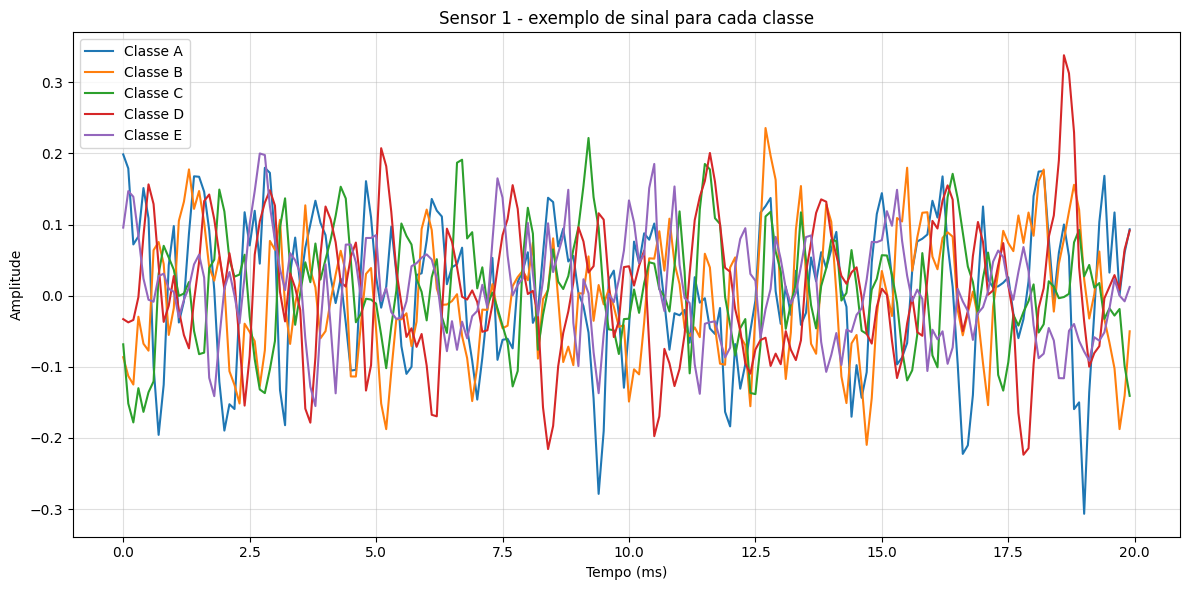

In [67]:
classes_unicas = np.unique(classes)

indices_exemplo = {}

for classe in classes_unicas:
    indices_exemplo[classe] = np.where(classes == classe)[0][0]

tempo_ms = np.arange(200) / FS * 1000

plt.figure(figsize=(12, 6))

for classe in classes_unicas:

    indice = indices_exemplo[classe]

    plt.plot(
        tempo_ms,
        dados_1[indice],
        label=classe
    )

plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude")
plt.title("Sensor 1 - exemplo de sinal para cada classe")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Interpretação

A inspeção visual de observações individuais não evidencia uma separação
clara entre as cinco classes no domínio do tempo.

Como uma única observação não representa a distribuição completa de cada
estado, foram extraídas características estatísticas de todas as observações
para avaliar diferenças de amplitude, dispersão e energia entre as classes.

In [68]:
def extrair_features_temporais(dados):

    features = pd.DataFrame()

    features["media"] = np.nanmean(dados, axis=1)
    features["std"] = np.nanstd(dados, axis=1)
    features["rms"] = np.sqrt(np.nanmean(dados**2, axis=1))
    features["pico_a_pico"] = (
        np.nanmax(dados, axis=1) -
        np.nanmin(dados, axis=1)
    )

    features["kurtosis"] = kurtosis(
        dados,
        axis=1,
        nan_policy="omit",
        fisher=False
    )

    return features


eda_s1 = extrair_features_temporais(dados_1)

eda_s1["classe"] = classes

resumo_s1 = (
    eda_s1
    .groupby("classe")
    .mean()
    .round(4)
)

resumo_s1

,media,std,rms,pico_a_pico,kurtosis
classe,,,,,
Classe A,0.0086,0.0901,0.0909,0.4821,2.9431
Classe B,0.0075,0.0886,0.0892,0.4765,3.0250
Classe C,0.0075,0.0785,0.0792,0.4135,2.8998
Classe D,0.0066,0.0831,0.0834,0.4385,2.9827
Classe E,0.0084,0.0797,0.0804,0.4208,2.9310


As características temporais indicam diferenças entre os estados,
principalmente no RMS, desvio-padrão e amplitude pico a pico.

Entretanto, diferenças entre médias não garantem separabilidade entre
classes. Por esse motivo, a distribuição do RMS também foi analisada.

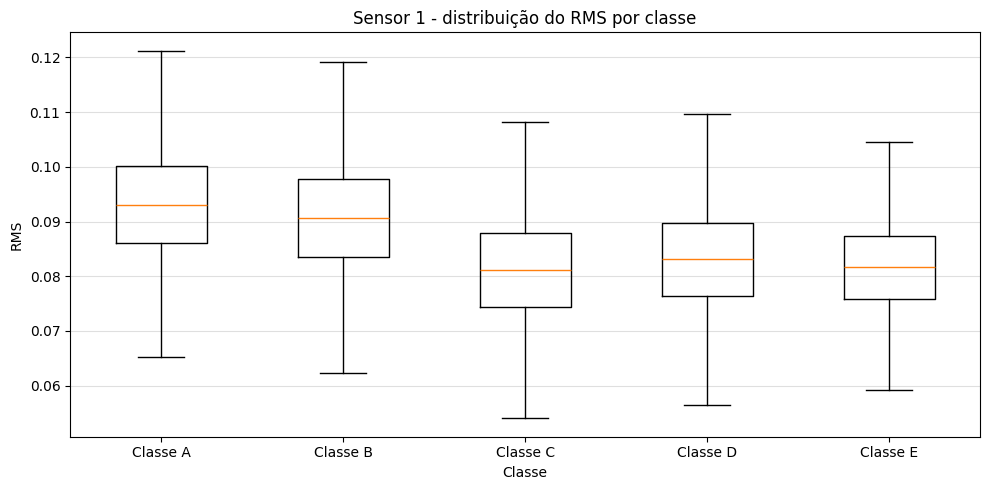

In [69]:
dados_boxplot = [
    eda_s1.loc[
        eda_s1["classe"] == classe,
        "rms"
    ]
    for classe in classes_unicas
]

plt.figure(figsize=(10, 5))

plt.boxplot(
    dados_boxplot,
    tick_labels=classes_unicas,
    showfliers=False
)

plt.xlabel("Classe")
plt.ylabel("RMS")
plt.title("Sensor 1 - distribuição do RMS por classe")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

Embora existam diferenças nas medianas do RMS, observa-se sobreposição
considerável entre as distribuições das classes.

Esse resultado indica que uma característica temporal isolada não é
suficiente para discriminar adequadamente os cinco estados de funcionamento,
motivando a investigação do conteúdo espectral dos sinais.

### 3.1 Análise no domínio da frequência

Como as características temporais apresentaram sobreposição entre as classes,
foi investigado o conteúdo espectral dos sinais.

Considerando uma frequência de amostragem de 10 kHz, a frequência máxima
representável é de 5 kHz, de acordo com o critério de Nyquist:

\[
f_{Nyquist} = \frac{f_s}{2} = 5\,kHz
\]

Para cada observação com 200 amostras, a resolução entre os bins da FFT é:

\[
\Delta f = \frac{f_s}{N} = \frac{10000}{200} = 50\,Hz
\]

Antes do cálculo da FFT, a componente DC é removida e uma janela de Hann
é aplicada para reduzir os efeitos de descontinuidade nas extremidades
das janelas e o vazamento espectral.

In [70]:
def calcular_espectro_medio(dados, classes, fs=FS):

    N = dados.shape[1]
    janela = np.hanning(N)

    frequencias = np.fft.rfftfreq(
        N,
        d=1/fs
    )

    espectros = {}

    for classe in np.unique(classes):

        mascara = classes == classe
        sinais = dados[mascara].copy()

        # Remoção da componente DC
        sinais = sinais - np.nanmean(
            sinais,
            axis=1,
            keepdims=True
        )

        # Aplicação da janela de Hann
        sinais = sinais * janela

        # FFT
        fft = np.abs(
            np.fft.rfft(
                sinais,
                axis=1
            )
        )

        espectros[classe] = np.nanmean(
            fft,
            axis=0
        )

    return frequencias, espectros

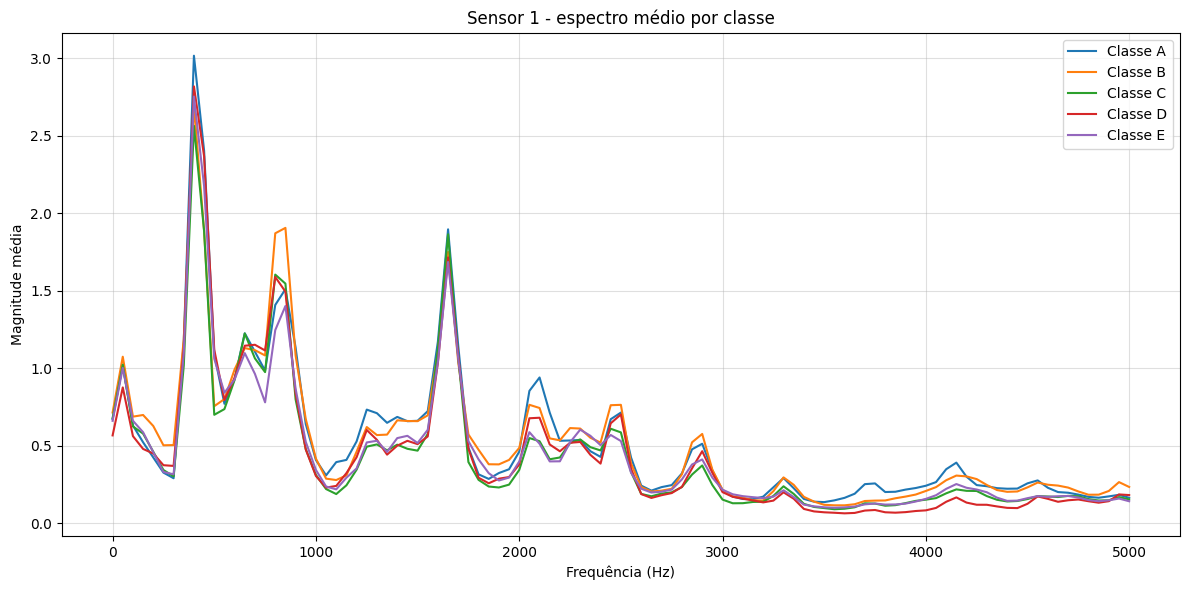

In [71]:
frequencias, espectros_s1 = calcular_espectro_medio(
    dados_1,
    classes
)

plt.figure(figsize=(12, 6))

for classe, espectro in espectros_s1.items():

    plt.plot(
        frequencias,
        espectro,
        label=classe
    )

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude média")
plt.title(
    "Sensor 1 - espectro médio por classe"
)

plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Interpretação

A análise espectral evidencia estruturas que não eram claramente observáveis
no domínio do tempo. As classes apresentam diferenças de magnitude em diversas
regiões do espectro, indicando que o conteúdo em frequência contém informação
relevante para a identificação dos estados de funcionamento.

Não é atribuída, nesta PoC, uma causa física específica aos componentes
espectrais observados, pois não foram disponibilizadas informações sobre
tipo e posicionamento dos sensores, características mecânicas da máquina,
velocidade de rotação ou condições de carga.

Em um projeto industrial, a interpretação física dessas assinaturas deverá
ser realizada em conjunto com especialistas de processo, manutenção,
automação e instrumentação.

## 4. Engenharia de Atributos

Com base na análise exploratória, foram construídas características nos
domínios do tempo e da frequência.

### Características temporais

- média;
- desvio-padrão;
- RMS;
- amplitude pico a pico;
- kurtosis;
- skewness;
- máximo absoluto;
- crest factor.

### Características espectrais

Na primeira abordagem, o espectro foi representado por:

- frequência dominante;
- centroide espectral;
- energia em seis bandas de frequência.

Essa representação inicial foi utilizada para avaliar sensores, comparar
algoritmos e investigar a contribuição dos domínios temporal e espectral.

In [72]:
def extrair_features_completas(dados, nome_sensor, fs=FS):

    # ----- Características temporais -----

    media = np.nanmean(dados, axis=1)
    std = np.nanstd(dados, axis=1)
    rms = np.sqrt(np.nanmean(dados**2, axis=1))

    minimo = np.nanmin(dados, axis=1)
    maximo = np.nanmax(dados, axis=1)

    pico_a_pico = maximo - minimo
    max_abs = np.nanmax(np.abs(dados), axis=1)

    kurt = kurtosis(
        dados,
        axis=1,
        nan_policy="omit",
        fisher=False
    )

    assimetria = skew(
        dados,
        axis=1,
        nan_policy="omit"
    )

    crest_factor = np.divide(
        max_abs,
        rms,
        out=np.zeros_like(max_abs),
        where=rms != 0
    )

    # ----- Preparação para análise espectral -----

    N = dados.shape[1]
    dados_fft = dados.copy()

    # Imputação pontual de NaN pela média da própria observação
    medias_linhas = np.nanmean(
        dados_fft,
        axis=1
    )

    linhas, colunas = np.where(
        np.isnan(dados_fft)
    )

    dados_fft[linhas, colunas] = medias_linhas[linhas]

    # Remoção da componente DC
    dados_fft = dados_fft - np.mean(
        dados_fft,
        axis=1,
        keepdims=True
    )

    # Janela de Hann
    janela = np.hanning(N)
    dados_fft = dados_fft * janela

    # FFT
    fft = np.abs(
        np.fft.rfft(
            dados_fft,
            axis=1
        )
    )

    frequencias = np.fft.rfftfreq(
        N,
        d=1/fs
    )

    # Frequência dominante
    indice_dominante = (
        np.argmax(fft[:, 1:], axis=1) + 1
    )

    freq_dominante = frequencias[
        indice_dominante
    ]

    # Centroide espectral
    soma_fft = np.sum(fft, axis=1)

    centroide = np.divide(
        np.sum(
            fft * frequencias,
            axis=1
        ),
        soma_fft,
        out=np.zeros_like(soma_fft),
        where=soma_fft != 0
    )

    # Bandas de frequência
    bandas = [
        (0, 500),
        (500, 1000),
        (1000, 2000),
        (2000, 3000),
        (3000, 4000),
        (4000, 5001)
    ]

    features = pd.DataFrame({
        f"{nome_sensor}_media": media,
        f"{nome_sensor}_std": std,
        f"{nome_sensor}_rms": rms,
        f"{nome_sensor}_pico_a_pico": pico_a_pico,
        f"{nome_sensor}_kurtosis": kurt,
        f"{nome_sensor}_skewness": assimetria,
        f"{nome_sensor}_max_abs": max_abs,
        f"{nome_sensor}_crest_factor": crest_factor,
        f"{nome_sensor}_freq_dominante": freq_dominante,
        f"{nome_sensor}_centroide_espectral": centroide
    })

    for inicio, fim in bandas:

        mascara = (
            (frequencias >= inicio) &
            (frequencias < fim)
        )

        energia = np.sum(
            fft[:, mascara]**2,
            axis=1
        )

        features[
            f"{nome_sensor}_energia_{inicio}_{fim}"
        ] = energia

    return features

In [73]:
features_s1 = extrair_features_completas(
    dados_1, "S1"
)

features_s2 = extrair_features_completas(
    dados_2, "S2"
)

features_s3 = extrair_features_completas(
    dados_3, "S3"
)

features_s5 = extrair_features_completas(
    dados_5, "S5"
)

X_inicial = pd.concat(
    [
        features_s1,
        features_s2,
        features_s3,
        features_s5
    ],
    axis=1
)

y = classes

print("Dimensão de X:", X_inicial.shape)
print("Dimensão de y:", y.shape)

print(
    "NaNs:",
    X_inicial.isna().sum().sum()
)

print(
    "Infinitos:",
    np.isinf(X_inicial.to_numpy()).sum()
)

print(
    "Features constantes:",
    (X_inicial.nunique() <= 1).sum()
)

Dimensão de X: (50000, 64)
Dimensão de y: (50000,)
NaNs: 0
Infinitos: 0
Features constantes: 0


### Tratamento de valores ausentes

Para as características temporais foram utilizadas operações que desconsideram
valores ausentes.

Para o cálculo da FFT, valores ausentes foram imputados pontualmente pela média
da própria observação, permitindo a continuidade do processamento espectral.

Essa estratégia foi adotada para a PoC. Em produção, a ocorrência de dados
ausentes deve ser monitorada como indicador de qualidade e saúde dos sensores,
e a política de tratamento deverá ser definida conforme a origem e o padrão
das perdas de dados.

## 5. Seleção dos Sensores

Após a avaliação da qualidade dos dados, os Sensores 1, 2, 3 e 5
permaneceram inicialmente como candidatos à modelagem.

Para avaliar quantitativamente a contribuição de cada sensor, foi realizado
um estudo de ablação utilizando o mesmo algoritmo, os mesmos atributos e a
mesma estratégia de divisão dos dados.

Foi utilizado Random Forest como modelo de referência, com divisão
estratificada de 80% dos dados para treinamento e 20% para teste.

Foram avaliados:

- Sensor 1 isoladamente;
- Sensor 2 isoladamente;
- Sensor 3 isoladamente;
- Sensor 5 isoladamente;
- combinação dos Sensores 1, 2 e 3;
- combinação dos Sensores 1, 2, 3 e 5.

In [74]:
conjuntos_sensores = {
    "Sensor 1":
        [c for c in X_inicial.columns if c.startswith("S1_")],

    "Sensor 2":
        [c for c in X_inicial.columns if c.startswith("S2_")],

    "Sensor 3":
        [c for c in X_inicial.columns if c.startswith("S3_")],

    "Sensor 5":
        [c for c in X_inicial.columns if c.startswith("S5_")],

    "Sensores 1+2+3":
        [
            c for c in X_inicial.columns
            if c.startswith(("S1_", "S2_", "S3_"))
        ],

    "Sensores 1+2+3+5":
        list(X_inicial.columns)
}

resultados_sensores = []

for nome, colunas in conjuntos_sensores.items():

    X_temp = X_inicial[colunas]

    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X_temp,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )

    modelo = RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    modelo.fit(
        X_train_temp,
        y_train_temp
    )

    pred = modelo.predict(
        X_test_temp
    )

    resultados_sensores.append({
        "Configuração": nome,
        "Accuracy": accuracy_score(
            y_test_temp,
            pred
        ),
        "Macro F1": f1_score(
            y_test_temp,
            pred,
            average="macro"
        )
    })

resultados_sensores = pd.DataFrame(
    resultados_sensores
)

resultados_sensores

,Configuração,Accuracy,Macro F1
0,Sensor 1,0.5767,0.572747
1,Sensor 2,0.6132,0.612529
2,Sensor 3,0.5721,0.569135
3,Sensor 5,0.2001,0.199999
4,Sensores 1+2+3,0.8112,0.809941
5,Sensores 1+2+3+5,0.7999,0.798570


### Interpretação

Os Sensores 1, 2 e 3 apresentaram capacidade discriminativa individual,
com melhor resultado isolado para o Sensor 2.

A combinação dos três sensores elevou a acurácia para aproximadamente
81%, resultado substancialmente superior ao obtido por qualquer sensor
isoladamente. Isso indica complementaridade entre as informações captadas
pelos Sensores 1, 2 e 3.

O Sensor 5 apresentou desempenho próximo ao nível esperado pelo acaso
em um problema balanceado de cinco classes (aproximadamente 20%).
Além disso, sua inclusão na combinação S1+S2+S3 reduziu o desempenho
do modelo.

Com base nesses resultados, os Sensores 1, 2 e 3 foram selecionados para
as etapas subsequentes da PoC.

In [75]:
colunas_selecionadas = [
    c for c in X_inicial.columns
    if c.startswith(("S1_", "S2_", "S3_"))
]

X_selected = X_inicial[
    colunas_selecionadas
].copy()

print(
    "Dimensão após seleção dos sensores:",
    X_selected.shape
)

Dimensão após seleção dos sensores: (50000, 48)


## 6. Seleção do Modelo de Machine Learning

Após a seleção dos Sensores 1, 2 e 3, foram comparados três algoritmos
supervisionados baseados em árvores:

- Random Forest;
- Extra Trees;
- HistGradientBoosting.

Todos os modelos foram avaliados utilizando a mesma divisão estratificada
de treinamento e teste, permitindo uma comparação consistente entre as
abordagens.

Foram utilizadas Accuracy e Macro F1 como métricas de avaliação.
Como o conjunto possui classes balanceadas, ambas fornecem uma visão
adequada do desempenho global, enquanto o Macro F1 também considera
o desempenho individual das classes.

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treinamento:", X_train.shape)
print("Teste:", X_test.shape)

Treinamento: (40000, 48)
Teste: (10000, 48)


In [77]:
modelos = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

resultados_modelos = []

for nome, modelo in modelos.items():

    modelo.fit(
        X_train,
        y_train
    )

    pred = modelo.predict(
        X_test
    )

    resultados_modelos.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(
            y_test,
            pred
        ),
        "Macro F1": f1_score(
            y_test,
            pred,
            average="macro"
        )
    })

resultados_modelos = (
    pd.DataFrame(resultados_modelos)
    .sort_values(
        "Accuracy",
        ascending=False
    )
)

resultados_modelos

,Modelo,Accuracy,Macro F1
2,HistGradientBoosting,0.8422,0.841659
1,Extra Trees,0.8196,0.818446
0,Random Forest,0.8112,0.809941


### Modelo selecionado nesta etapa

O HistGradientBoosting apresentou o melhor desempenho entre os modelos
avaliados, alcançando aproximadamente 84,2% de acurácia.

Esse modelo foi selecionado para os experimentos subsequentes de
engenharia de atributos.

## 7. Análise da Contribuição dos Atributos

Após a seleção dos Sensores 1, 2 e 3 e do HistGradientBoosting como
modelo de referência, foi realizado um estudo de ablação para avaliar
separadamente a contribuição das características temporais e espectrais.

Foram comparadas três configurações:

- características temporais;
- características espectrais;
- combinação das características temporais e espectrais.

O objetivo foi identificar qual representação dos sinais apresenta maior
capacidade discriminativa para os diferentes estados de funcionamento.

In [78]:
features_temporais = [
    "media",
    "std",
    "rms",
    "pico_a_pico",
    "kurtosis",
    "skewness",
    "max_abs",
    "crest_factor"
]

colunas_temporais = [
    c for c in X_selected.columns
    if any(
        c.endswith("_" + feature)
        for feature in features_temporais
    )
]

colunas_espectrais = [
    c for c in X_selected.columns
    if (
        "freq_dominante" in c
        or "centroide_espectral" in c
        or "_energia_" in c
    )
]

print(
    "Características temporais:",
    len(colunas_temporais)
)

print(
    "Características espectrais:",
    len(colunas_espectrais)
)

Características temporais: 24
Características espectrais: 24


In [79]:
configuracoes_features = {
    "Temporais":
        colunas_temporais,

    "Espectrais":
        colunas_espectrais,

    "Temporais + Espectrais":
        list(X_selected.columns)
}

resultados_features = []

for nome, colunas in configuracoes_features.items():

    X_temp = X_selected[colunas]

    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X_temp,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )

    modelo = HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    )

    modelo.fit(
        X_train_temp,
        y_train_temp
    )

    pred = modelo.predict(
        X_test_temp
    )

    resultados_features.append({
        "Representação": nome,
        "Nº atributos": len(colunas),
        "Accuracy": accuracy_score(
            y_test_temp,
            pred
        ),
        "Macro F1": f1_score(
            y_test_temp,
            pred,
            average="macro"
        )
    })

resultados_features = pd.DataFrame(
    resultados_features
)

resultados_features

,Representação,Nº atributos,Accuracy,Macro F1
0,Temporais,24,0.5046,0.503503
1,Espectrais,24,0.8164,0.815799
2,Temporais + Espectrais,48,0.8422,0.841659


### Interpretação

Os resultados mostram que as características espectrais apresentam
capacidade discriminativa substancialmente superior às características
temporais.

As características temporais isoladamente alcançaram aproximadamente
50,5% de acurácia, enquanto as características espectrais alcançaram
aproximadamente 81,6%.

A combinação dos dois domínios elevou o desempenho para aproximadamente
84,2%, indicando que, embora a informação discriminativa esteja
predominantemente no domínio da frequência, as características temporais
fornecem informação complementar.

Esse resultado motivou o refinamento da representação espectral,
preservando maior resolução do conteúdo em frequência.

## 8. Refinamento da Representação Espectral

A representação espectral inicial utilizava frequência dominante,
centroide espectral e energia agregada em seis bandas.

Como o estudo de ablação demonstrou que o domínio da frequência concentra
a maior parte da informação discriminativa, foi avaliada uma representação
espectral de maior resolução.

Com frequência de amostragem de 10 kHz e janelas de 200 amostras, a FFT
apresenta resolução de 50 Hz. Foram utilizados os coeficientes de magnitude
correspondentes às frequências de 50 Hz a 5 kHz, excluindo a componente DC.

Para cada sensor são obtidos 100 atributos espectrais. Considerando os
Sensores 1, 2 e 3, a representação possui 300 atributos de FFT.

In [80]:
def extrair_fft_features(
    dados,
    nome_sensor,
    fs=FS
):

    N = dados.shape[1]

    dados_fft = dados.copy()

    # Imputação pontual de NaN pela média da observação
    medias = np.nanmean(
        dados_fft,
        axis=1
    )

    linhas, colunas = np.where(
        np.isnan(dados_fft)
    )

    dados_fft[linhas, colunas] = medias[linhas]

    # Remoção da componente DC
    dados_fft = dados_fft - np.mean(
        dados_fft,
        axis=1,
        keepdims=True
    )

    # Janela de Hann
    janela = np.hanning(N)
    dados_fft = dados_fft * janela

    # Transformada de Fourier
    fft = np.abs(
        np.fft.rfft(
            dados_fft,
            axis=1
        )
    )

    frequencias = np.fft.rfftfreq(
        N,
        d=1/fs
    )

    # Exclusão da componente DC (0 Hz)
    fft = fft[:, 1:]
    frequencias = frequencias[1:]

    nomes_colunas = [
        f"{nome_sensor}_FFT_{int(freq)}Hz"
        for freq in frequencias
    ]

    return pd.DataFrame(
        fft,
        columns=nomes_colunas
    )

In [81]:
fft_s1 = extrair_fft_features(
    dados_1,
    "S1"
)

fft_s2 = extrair_fft_features(
    dados_2,
    "S2"
)

fft_s3 = extrair_fft_features(
    dados_3,
    "S3"
)

X_fft = pd.concat(
    [
        fft_s1,
        fft_s2,
        fft_s3
    ],
    axis=1
)

print(
    "Dimensão da representação FFT:",
    X_fft.shape
)

print(
    "NaNs:",
    X_fft.isna().sum().sum()
)

print(
    "Infinitos:",
    np.isinf(X_fft.to_numpy()).sum()
)

Dimensão da representação FFT: (50000, 300)
NaNs: 0
Infinitos: 0


In [82]:
X_train_fft, X_test_fft, y_train_fft, y_test_fft = train_test_split(
    X_fft,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

modelo_fft = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE
)

modelo_fft.fit(
    X_train_fft,
    y_train_fft
)

pred_fft = modelo_fft.predict(
    X_test_fft
)

acc_fft = accuracy_score(
    y_test_fft,
    pred_fft
)

f1_fft = f1_score(
    y_test_fft,
    pred_fft,
    average="macro"
)

print(
    "Accuracy FFT:",
    round(acc_fft, 4)
)

print(
    "Macro F1 FFT:",
    round(f1_fft, 4)
)

Accuracy FFT: 0.9407
Macro F1 FFT: 0.9407


In [83]:
X_temporal = (
    X_selected[colunas_temporais]
    .reset_index(drop=True)
)

X_fft_reset = (
    X_fft
    .reset_index(drop=True)
)

X_final = pd.concat(
    [
        X_temporal,
        X_fft_reset
    ],
    axis=1
)

print(
    "Dimensão da representação final:",
    X_final.shape
)

Dimensão da representação final: (50000, 324)


In [84]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

modelo_final = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE
)

modelo_final.fit(
    X_train_final,
    y_train_final
)

pred_final = modelo_final.predict(
    X_test_final
)

acc_final = accuracy_score(
    y_test_final,
    pred_final
)

f1_final = f1_score(
    y_test_final,
    pred_final,
    average="macro"
)

print(
    "Accuracy:",
    round(acc_final, 4)
)

print(
    "Macro F1:",
    round(f1_final, 4)
)

Accuracy: 0.9513
Macro F1: 0.9513


### Evolução da representação

A representação espectral detalhada elevou a acurácia de aproximadamente
84,2% para 94,1%, demonstrando que as bandas agregadas utilizadas
inicialmente eliminavam parte da informação discriminativa.

A combinação da FFT detalhada com as características temporais elevou
o resultado para aproximadamente 95,1%.

Assim, a principal evolução de desempenho da PoC não ocorreu pela adoção
de um algoritmo mais complexo, mas pelo refinamento da representação dos
sinais orientado pelos resultados da análise exploratória e dos experimentos
de ablação.

## 9. Avaliação do Modelo Final

O modelo selecionado foi avaliado inicialmente em um conjunto de teste
estratificado correspondente a 20% das observações.

Além das métricas globais de Accuracy e Macro F1, foram analisados
Precision, Recall e F1-score para cada classe, bem como a matriz de confusão.

Essa análise permite verificar se o desempenho global é distribuído de
forma equilibrada entre os diferentes estados de funcionamento.

In [85]:
print(
    classification_report(
        y_test_final,
        pred_final,
        digits=4
    )
)

              precision    recall  f1-score   support

    Classe A     0.9705    0.9720    0.9713      2000
    Classe B     0.9407    0.9445    0.9426      2000
    Classe C     0.9347    0.9370    0.9358      2000
    Classe D     0.9805    0.9825    0.9815      2000
    Classe E     0.9298    0.9205    0.9251      2000

    accuracy                         0.9513     10000
   macro avg     0.9513    0.9513    0.9513     10000
weighted avg     0.9513    0.9513    0.9513     10000



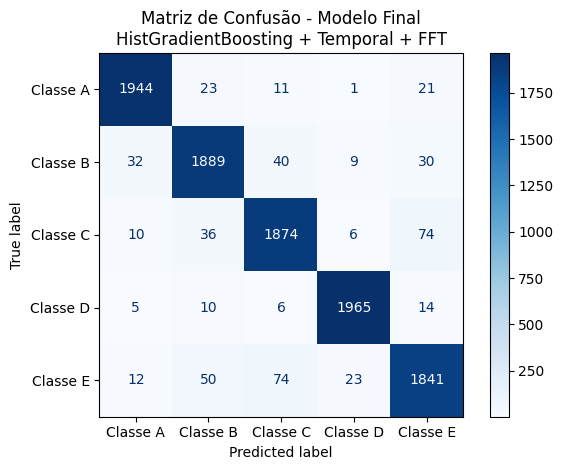

In [86]:
ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    pred_final,
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Matriz de Confusão - Modelo Final\n"
    "HistGradientBoosting + Temporal + FFT"
)

plt.tight_layout()
plt.show()

### Interpretação dos resultados

O modelo final apresentou desempenho equilibrado entre as cinco classes,
com F1-score superior a 92% em todos os estados avaliados.

A Classe D apresentou o melhor desempenho, enquanto a Classe E permaneceu
como a condição de maior dificuldade relativa para o modelo.

A matriz de confusão mostra que a principal confusão residual ocorre entre
as Classes C e E. Entretanto, o refinamento da representação espectral
reduziu substancialmente essa dificuldade em relação à representação
espectral agregada utilizada nas etapas anteriores.

Os resultados indicam que a combinação de informações temporais e
espectrais dos Sensores 1, 2 e 3 é capaz de representar adequadamente
os diferentes estados presentes no conjunto de dados disponibilizado.

## 10. Validação Cruzada

Para avaliar a estabilidade do desempenho em diferentes particionamentos
do conjunto de dados, foi realizada validação cruzada estratificada com
cinco folds.

Em cada iteração, a proporção das cinco classes foi preservada.
Foram avaliadas Accuracy e Macro F1.

In [87]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

modelo_cv = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro"
}

resultados_cv = cross_validate(
    modelo_cv,
    X_final,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

accuracy_folds = resultados_cv[
    "test_accuracy"
]

f1_folds = resultados_cv[
    "test_f1_macro"
]

print("Accuracy por fold:")
print(accuracy_folds)

print("\nMacro F1 por fold:")
print(f1_folds)

print(
    "\nAccuracy média:",
    round(accuracy_folds.mean(), 4)
)

print(
    "Desvio-padrão da Accuracy:",
    round(accuracy_folds.std(), 6)
)

print(
    "\nMacro F1 médio:",
    round(f1_folds.mean(), 4)
)

print(
    "Desvio-padrão do Macro F1:",
    round(f1_folds.std(), 6)
)

Accuracy por fold:
[0.9485 0.9492 0.9496 0.9489 0.9497]

Macro F1 por fold:
[0.94852436 0.94914302 0.9496297  0.94892534 0.94976693]

Accuracy média: 0.9492
Desvio-padrão da Accuracy: 0.000445

Macro F1 médio: 0.9492
Desvio-padrão do Macro F1: 0.000456


### Estabilidade do modelo

A validação cruzada estratificada com cinco folds apresentou:

- **Accuracy média: aproximadamente 94,92%**
- **Macro F1 médio: aproximadamente 94,92%**
- **Desvio-padrão da Accuracy: aproximadamente 0,04 ponto percentual**

A pequena variação entre os folds indica estabilidade do desempenho do
modelo nos diferentes particionamentos avaliados.

### Limitação da validação

O conjunto de dados disponibilizado não contém identificadores de máquina,
ensaio, sessão, período de aquisição ou outros metadados que permitam
estabelecer grupos fisicamente independentes.

Por esse motivo, a validação da PoC foi realizada por particionamento
estratificado.

Em uma implantação industrial, a validação definitiva deverá considerar
dados independentes por máquina, ensaio, período ou campanha de aquisição,
reduzindo o risco de dependência entre dados utilizados no treinamento
e na avaliação.

In [88]:
resumo_experimentos = pd.DataFrame({
    "Experimento": [
        "Random Forest - S1+S2+S3+S5",
        "Random Forest - S1+S2+S3",
        "HistGradientBoosting - features agregadas",
        "HistGradientBoosting - FFT detalhada",
        "HistGradientBoosting - Temporal + FFT detalhada"
    ],

    "Accuracy": [
        0.7999,
        0.8112,
        0.8422,
        0.9407,
        0.9513
    ]
})

resumo_experimentos

,Experimento,Accuracy
0,Random Forest - S1+S2+S3+S5,0.7999
1,Random Forest - S1+S2+S3,0.8112
2,HistGradientBoosting - features agregadas,0.8422
3,HistGradientBoosting - FFT detalhada,0.9407
4,HistGradientBoosting - Temporal + FFT detalhada,0.9513


### Síntese da evolução

A evolução experimental demonstra três decisões principais:

1. **Seleção de sensores:** a combinação dos Sensores 1, 2 e 3 apresentou
   melhor desempenho que a inclusão do Sensor 5.

2. **Seleção do modelo:** o HistGradientBoosting apresentou melhor desempenho
   que Random Forest e Extra Trees na representação inicial.

3. **Representação dos sinais:** o maior ganho de desempenho ocorreu com
   o refinamento da representação espectral, elevando a acurácia de
   aproximadamente 84,2% para 95,1%.

Os resultados mostram que a qualidade da representação dos dados foi mais
determinante para o desempenho final do que simplesmente aumentar a
complexidade do algoritmo de classificação.

## 11. Conclusões da Prova de Conceito

A PoC demonstrou viabilidade técnica para classificação dos cinco estados
de funcionamento presentes no conjunto de dados disponibilizado.

O pipeline desenvolvido contemplou avaliação da qualidade dos dados,
análise exploratória, pré-processamento, engenharia de atributos, seleção
de sensores, comparação de algoritmos e validação do modelo.

A solução final utiliza os Sensores 1, 2 e 3, características temporais
e representação espectral baseada em FFT, combinadas com o algoritmo
HistGradientBoosting.

No conjunto de teste estratificado, o modelo alcançou aproximadamente
**95,13% de Accuracy e 95,13% de Macro F1**. Na validação cruzada
estratificada com cinco folds, apresentou aproximadamente **94,92% de
Accuracy média**, com baixa variabilidade entre os folds.

Os resultados devem ser interpretados como evidência de viabilidade da
PoC para os dados fornecidos, e não como garantia de desempenho em ambiente
industrial. A implantação deverá incluir validação com dados independentes,
monitoramento da qualidade dos sensores, integração com a infraestrutura
industrial e acompanhamento contínuo do desempenho do modelo.